In [194]:
import pandas as pd
df=pd.read_csv("Indian_Kids_Screen_Time.csv")

In [195]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [196]:
df.tail()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban
9711,15,Female,6.12,TV,True,0.33,Anxiety,Urban


In [197]:
df.shape

(9712, 8)

In [198]:
df.size

77696

In [199]:
df.dtypes

Age                                    int64
Gender                                   str
Avg_Daily_Screen_Time_hr             float64
Primary_Device                           str
Exceeded_Recommended_Limit              bool
Educational_to_Recreational_Ratio    float64
Health_Impacts                           str
Urban_or_Rural                           str
dtype: object

In [200]:
df.columns=df.columns.str.lower().str.replace(' ','_')

In [201]:
df.duplicated().sum() 

np.int64(44)

In [202]:
df=df.drop_duplicates(inplace=False)

In [203]:
df.duplicated().sum()

np.int64(0)

In [204]:
df.isnull().sum()

age                                     0
gender                                  0
avg_daily_screen_time_hr                0
primary_device                          0
exceeded_recommended_limit              0
educational_to_recreational_ratio       0
health_impacts                       3180
urban_or_rural                          0
dtype: int64

In [205]:
df.loc[df['health_impacts'].isna(),'health_impacts']='No Health Impact'

In [206]:
(df['health_impacts']=='No Health Impact').sum()

np.int64(3180)

In [207]:
df['health_impacts'].value_counts()

health_impacts
No Health Impact                                 3180
Poor Sleep                                       2264
Poor Sleep, Eye Strain                            978
Eye Strain                                        644
Poor Sleep, Anxiety                               607
Poor Sleep, Obesity Risk                          452
Anxiety                                           385
Poor Sleep, Eye Strain, Anxiety                   258
Obesity Risk                                      252
Poor Sleep, Eye Strain, Obesity Risk              188
Eye Strain, Anxiety                               135
Eye Strain, Obesity Risk                          106
Poor Sleep, Anxiety, Obesity Risk                  78
Anxiety, Obesity Risk                              69
Poor Sleep, Eye Strain, Anxiety, Obesity Risk      37
Eye Strain, Anxiety, Obesity Risk                  35
Name: count, dtype: int64

In [208]:
df.shape#shape of the dataframe after dropping duplicates and filling null values in health_impacts column with 'No Health Impact'

(9668, 8)

In [209]:
df['health_impacts'].unique()

<StringArray>
[                       'Poor Sleep, Eye Strain',
                                    'Poor Sleep',
                              'No Health Impact',
                           'Poor Sleep, Anxiety',
                      'Poor Sleep, Obesity Risk',
                                    'Eye Strain',
                                  'Obesity Risk',
                                       'Anxiety',
             'Poor Sleep, Anxiety, Obesity Risk',
                      'Eye Strain, Obesity Risk',
             'Eye Strain, Anxiety, Obesity Risk',
                         'Anxiety, Obesity Risk',
          'Poor Sleep, Eye Strain, Obesity Risk',
               'Poor Sleep, Eye Strain, Anxiety',
 'Poor Sleep, Eye Strain, Anxiety, Obesity Risk',
                           'Eye Strain, Anxiety']
Length: 16, dtype: str

In [210]:
df['gender'].unique()#unique values

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [211]:
df['gender'].value_counts()#count of each unique value

gender
Male      4928
Female    4740
Name: count, dtype: int64

In [212]:
df['primary_device'].unique()#unique values in primary_device column

<StringArray>
['Smartphone', 'Laptop', 'TV', 'Tablet']
Length: 4, dtype: str

In [213]:
df['primary_device'].value_counts()#count of each unique value in primary_device column

primary_device
Smartphone    4540
TV            2478
Laptop        1431
Tablet        1219
Name: count, dtype: int64

In [214]:
df['exceeded_recommended_limit'].unique()#unique values in excess_screen_time column

array([ True, False])

In [215]:
df['health_impacts']=df['health_impacts'].str.replace(',  ',',')#remove space after comma in health_impacts column

In [216]:
df['health_impacts']=df['health_impacts'].str.strip()#strip leading and trailing whitespace from health_impacts column a

In [217]:
df['health_impacts'].unique()#unique values in health_impacts column

<StringArray>
[                       'Poor Sleep, Eye Strain',
                                    'Poor Sleep',
                              'No Health Impact',
                           'Poor Sleep, Anxiety',
                      'Poor Sleep, Obesity Risk',
                                    'Eye Strain',
                                  'Obesity Risk',
                                       'Anxiety',
             'Poor Sleep, Anxiety, Obesity Risk',
                      'Eye Strain, Obesity Risk',
             'Eye Strain, Anxiety, Obesity Risk',
                         'Anxiety, Obesity Risk',
          'Poor Sleep, Eye Strain, Obesity Risk',
               'Poor Sleep, Eye Strain, Anxiety',
 'Poor Sleep, Eye Strain, Anxiety, Obesity Risk',
                           'Eye Strain, Anxiety']
Length: 16, dtype: str

In [218]:
df['health_impacts_list'] = df['health_impacts'].str.split(',')#split health_impacts column into  a list of health impacts

In [219]:
df[['health_impacts','health_impacts_list']].head()

,health_impacts,health_impacts_list
0,"Poor Sleep, Eye Strain","[Poor Sleep, Eye Strain]"
1,Poor Sleep,[Poor Sleep]
2,Poor Sleep,[Poor Sleep]
3,No Health Impact,[No Health Impact]
4,"Poor Sleep, Anxiety","[Poor Sleep, Anxiety]"


In [220]:
df_exploded=df.explode('health_impacts_list')#explode health_impacts_list column to create a new row for each health impact

In [221]:
df_exploded['health_impacts_list'].value_counts()#count of each unique health impact in health_impacts_list column after exploding the list into new rows

health_impacts_list
Poor Sleep          4862
No Health Impact    3180
 Eye Strain         1461
 Anxiety            1150
 Obesity Risk        965
Eye Strain           920
Anxiety              454
Obesity Risk         252
Name: count, dtype: int64

In [222]:
df_exploded[df_exploded['health_impacts_list']=='No Health Impact']#filter rows where health_impacts_list column contains 'No Health Impact'

,age,gender,avg_daily_screen_time_hr,primary_device,exceeded_recommended_limit,educational_to_recreational_ratio,health_impacts,urban_or_rural,health_impacts_list
3,15,Female,1.21,Laptop,False,0.39,No Health Impact,Urban,No Health Impact
6,17,Male,2.97,TV,False,0.48,No Health Impact,Rural,No Health Impact
7,10,Male,2.74,TV,True,0.54,No Health Impact,Urban,No Health Impact
19,9,Female,0.00,TV,False,0.42,No Health Impact,Urban,No Health Impact
22,9,Female,1.63,Tablet,False,0.58,No Health Impact,Urban,No Health Impact
...,...,...,...,...,...,...,...,...,...
9695,12,Female,2.69,Smartphone,False,0.48,No Health Impact,Urban,No Health Impact
9697,16,Female,4.74,Smartphone,True,0.41,No Health Impact,Rural,No Health Impact
9699,10,Female,2.85,TV,True,0.49,No Health Impact,Urban,No Health Impact
9701,16,Male,6.08,Smartphone,True,0.38,No Health Impact,Urban,No Health Impact


In [223]:
df_exploded.duplicated().sum()#check for duplicate rows in exploded dataframe

np.int64(0)

In [224]:
(df_exploded['health_impacts_list']=='No Health Impact').sum()

np.int64(3180)

In [225]:
df['age'].min()

np.int64(8)

In [226]:
df['age'].max()

np.int64(18)

age bands


In [227]:
bins=[7,12,15,19]#define bins for age groups
labels=['8-12 children ','13-15 young teens','16-18 teens']#define labels for age groups
df['age_group']=pd.cut(df['age'],bins=bins,labels=labels,right=False)#create age_group column by categorizing age into defined bins and labels

In [228]:
df[['age','age_group']].head()

,age,age_group
0,14,13-15 young teens
1,11,8-12 children
2,18,16-18 teens
3,15,16-18 teens
4,12,13-15 young teens


In [229]:
df['age_group'].value_counts()#count of each age group in age_group column

age_group
8-12 children        3501
16-18 teens          3495
13-15 young teens    2672
Name: count, dtype: int64

divice shares

In [230]:
df['primary_device'].value_counts()#how many users use each device

primary_device
Smartphone    4540
TV            2478
Laptop        1431
Tablet        1219
Name: count, dtype: int64

In [231]:
total=len(df)#total number of rows in the dataframe
print(total)

9668


In [232]:
(df['primary_device'].value_counts()/total)*100 #device share in percentage

primary_device
Smartphone    46.959040
TV            25.630947
Laptop        14.801407
Tablet        12.608606
Name: count, dtype: float64

activity shares

In [233]:
df['activity_type'] =''#create a activity_type column
df.loc[df['educational_to_recreational_ratio']>1,'activity_type']='educational usage'
df.loc[df['educational_to_recreational_ratio']<1,'activity_type']='recreatinal usage'
df.loc[df['educational_to_recreational_ratio']==1,'activity_type']='balanced usage'
counts=df['activity_type'].value_counts()#count of each unique value in activity_type column
print(counts)
total=len(df)
print(total)
activity_share=(df['activity_type'].value_counts()/total)*100#percentage of each activity type
print(activity_share)

activity_type
recreatinal usage    9668
Name: count, dtype: int64
9668
activity_type
recreatinal usage    100.0
Name: count, dtype: float64


### creating a new column 'health_issue_present'

In [234]:
health_issue_present='no health issue'
#create a new column health_issue_present and set it to 'health issue present'
#if health_impacts_list column does not contain 'No Health Impact'
df.loc[df['health_impacts']!='No Health Impact','health_issue_present']='health issue'
#set health_issue_present column to 'no health issue' if health_impacts_list column contains 'No Health Impact'
df.loc[df['health_impacts']=='No Health Impact','health_issue_present']='no health issue'
print(df['health_issue_present'].value_counts())#count of each unique value in health_issue_present col

health_issue_present
health issue       6488
no health issue    3180
Name: count, dtype: int64


### creating a new column 'health_issue_count'

In [235]:
#count no of health issues
df['health_issue_count'] = df['health_impacts_list'].str.len()
df.loc[df['health_impacts']=='No Health Impact','health_issue_count']=0#set health_issue_count to 0 if health_impacts column contains 'No Health Impact'
print(df[['health_impacts','health_issue_count']].head()) 

           health_impacts  health_issue_count
0  Poor Sleep, Eye Strain                   2
1              Poor Sleep                   1
2              Poor Sleep                   1
3        No Health Impact                   0
4     Poor Sleep, Anxiety                   2


### creating a new column health_status

In [236]:
#health status
df['health_status']='good health'
df.loc[df['health_issue_count']>0,'health_status']='poor health'
df[['health_impacts','health_issue_count','health_status']].head()
#print(df['health_status'].value_counts())#count of each unique value in health_status column

,health_impacts,health_issue_count,health_status
0,"Poor Sleep, Eye Strain",2,poor health
1,Poor Sleep,1,poor health
2,Poor Sleep,1,poor health
3,No Health Impact,0,good health
4,"Poor Sleep, Anxiety",2,poor health


### creating a new column device_type

In [237]:
df['device_type']=''
df.loc[df['primary_device']=='Smartphone','device_type']='portable'
df.loc[df['primary_device']=='Laptop','device_type']='portable'
df.loc[df['primary_device']=='Tablet','device_type']='portable'
df.loc[df['primary_device']=='TV','device_type']='wall-mounted'
df[['primary_device','device_type']].head()

,primary_device,device_type
0,Smartphone,portable
1,Laptop,portable
2,TV,wall-mounted
3,Laptop,portable
4,Smartphone,portable


### creating a new column screen_time_category

In [238]:
df['avg_daily_screen_time_hr'].max()


np.float64(13.89)

In [239]:
df['avg_daily_screen_time_hr'].min()

np.float64(0.0)

In [240]:
#categorize avg_daily_screen_time_hr into defined bins and labels to create screen_time_category column
bins=[0,2,8,14]
labels=['0-2 low ','3-8 moderate','9-14 high']
df['screen_time_category']=pd.cut(df['avg_daily_screen_time_hr'],bins=bins,labels=labels,right=False)

In [241]:
print(df['screen_time_category'].value_counts())

screen_time_category
3-8 moderate    8701
0-2 low          792
9-14 high        175
Name: count, dtype: int64


### creating a new column weekday flg

In [242]:
mean_screen_time=df['avg_daily_screen_time_hr'].mean()

In [243]:
df['weekday_flag']=''
df.loc[df['avg_daily_screen_time_hr']>mean_screen_time,'weekday_flag']='weekend'
df.loc[df['avg_daily_screen_time_hr']<mean_screen_time,'weekday_flag']='weekday'
print(df['weekday_flag'].value_counts())
print(df[['avg_daily_screen_time_hr','weekday_flag']].head())

weekday_flag
weekend    5022
weekday    4646
Name: count, dtype: int64
   avg_daily_screen_time_hr weekday_flag
0                      3.99      weekday
1                      4.61      weekend
2                      3.73      weekday
3                      1.21      weekday
4                      5.89      weekend


In [244]:
df[['avg_daily_screen_time_hr','activity_type','weekday_flag']].tail(5)

,avg_daily_screen_time_hr,activity_type,weekday_flag
9707,3.26,recreatinal usage,weekday
9708,4.43,recreatinal usage,weekend
9709,5.62,recreatinal usage,weekend
9710,5.60,recreatinal usage,weekend
9711,6.12,recreatinal usage,weekend


In [245]:
print("final updated dataset")
df.head()


final updated dataset


,age,gender,avg_daily_screen_time_hr,primary_device,exceeded_recommended_limit,educational_to_recreational_ratio,health_impacts,urban_or_rural,health_impacts_list,age_group,activity_type,health_issue_present,health_issue_count,health_status,device_type,screen_time_category,weekday_flag
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,"[Poor Sleep, Eye Strain]",13-15 young teens,recreatinal usage,health issue,2,poor health,portable,3-8 moderate,weekday
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,[Poor Sleep],8-12 children,recreatinal usage,health issue,1,poor health,portable,3-8 moderate,weekend
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,[Poor Sleep],16-18 teens,recreatinal usage,health issue,1,poor health,wall-mounted,3-8 moderate,weekday
3,15,Female,1.21,Laptop,False,0.39,No Health Impact,Urban,[No Health Impact],16-18 teens,recreatinal usage,no health issue,0,good health,portable,0-2 low,weekday
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,"[Poor Sleep, Anxiety]",13-15 young teens,recreatinal usage,health issue,2,poor health,portable,3-8 moderate,weekend


In [246]:
print("updated columns")
df.columns

updated columns


Index(['age', 'gender', 'avg_daily_screen_time_hr', 'primary_device',
       'exceeded_recommended_limit', 'educational_to_recreational_ratio',
       'health_impacts', 'urban_or_rural', 'health_impacts_list', 'age_group',
       'activity_type', 'health_issue_present', 'health_issue_count',
       'health_status', 'device_type', 'screen_time_category', 'weekday_flag'],
      dtype='str')

In [247]:
#univariate  analysisd
df['avg_daily_screen_time_hr'].describe()


count    9668.000000
mean        4.367780
std         1.703002
min         0.000000
25%         3.427500
50%         4.440000
75%         5.380000
max        13.890000
Name: avg_daily_screen_time_hr, dtype: float64

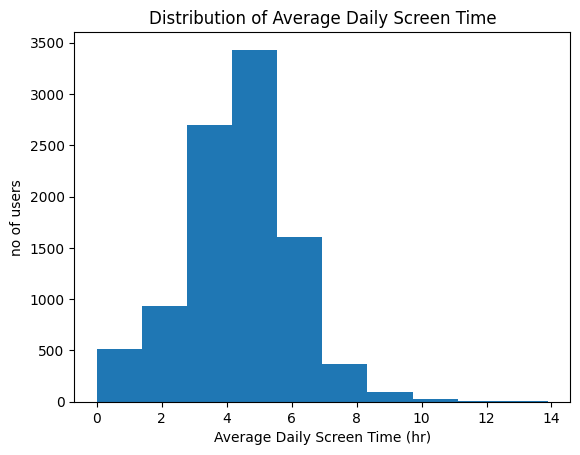

In [248]:
import matplotlib.pyplot as plt
plt.hist(df['avg_daily_screen_time_hr'], bins=10)
plt.xlabel('Average Daily Screen Time (hr)')
plt.ylabel('no of users')
plt.title('Distribution of Average Daily Screen Time')
plt.show()



In [249]:
df['health_issue_present'].value_counts()

health_issue_present
health issue       6488
no health issue    3180
Name: count, dtype: int64

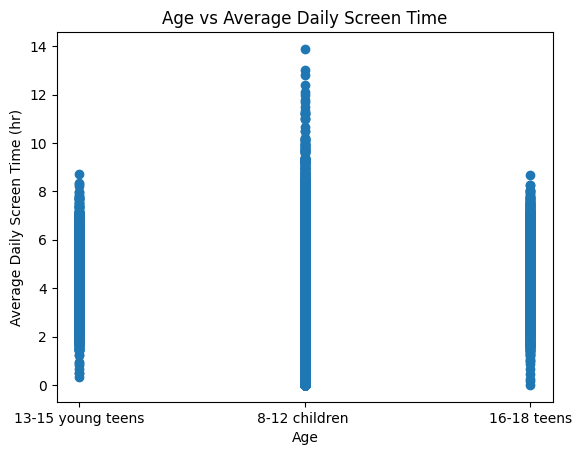

In [250]:
#bivariate analysis
plt.scatter(df['age_group'],df['avg_daily_screen_time_hr'])
plt.xlabel('Age')
plt.ylabel('Average Daily Screen Time (hr)')
plt.title('Age vs Average Daily Screen Time')
plt.show()

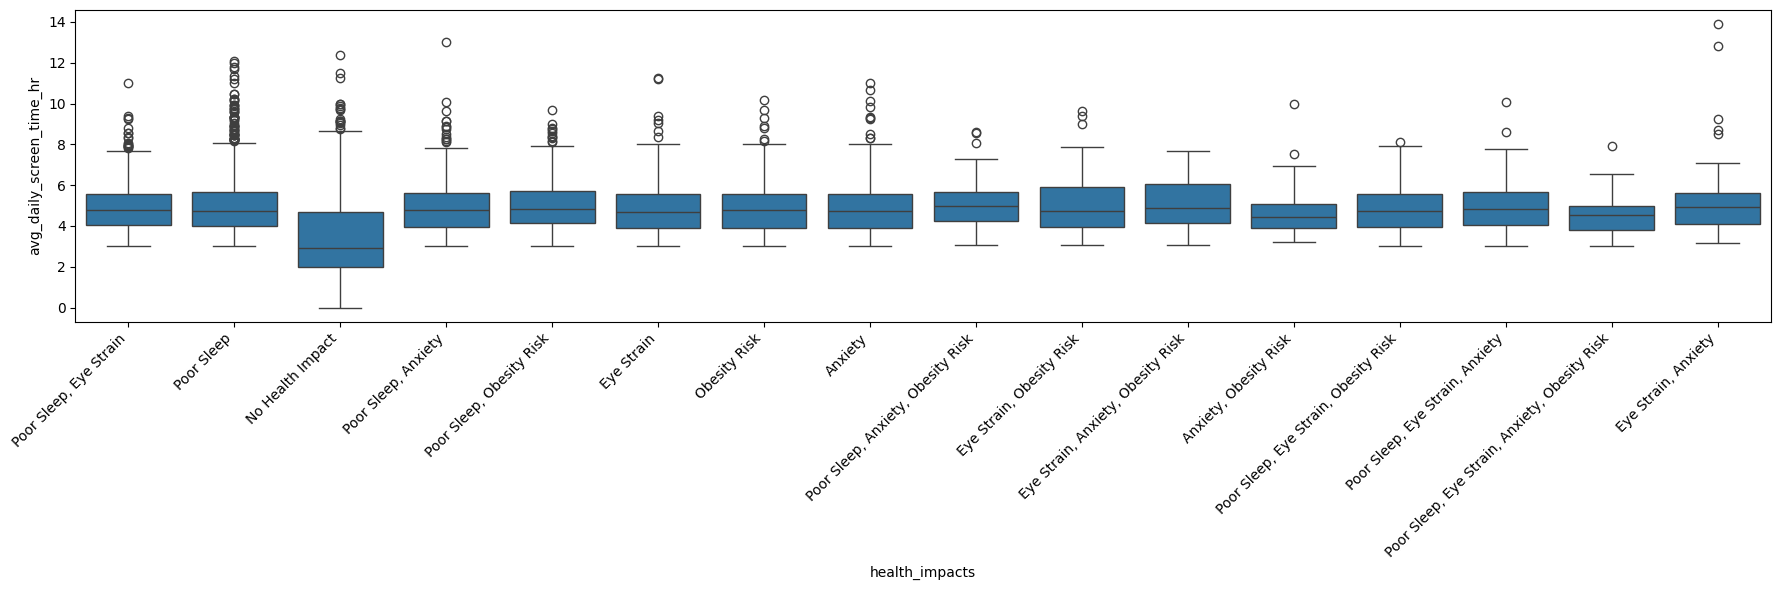

In [251]:
import seaborn as sns
plt.figure(figsize=(18,6))
sns.boxplot(x='health_impacts', y='avg_daily_screen_time_hr', data=df)
plt.xticks(rotation=45,ha='right') 
plt.tight_layout()                  
plt.show()

# **All possible Plots**

## Univariate Analysis-Numerical

### histogram 

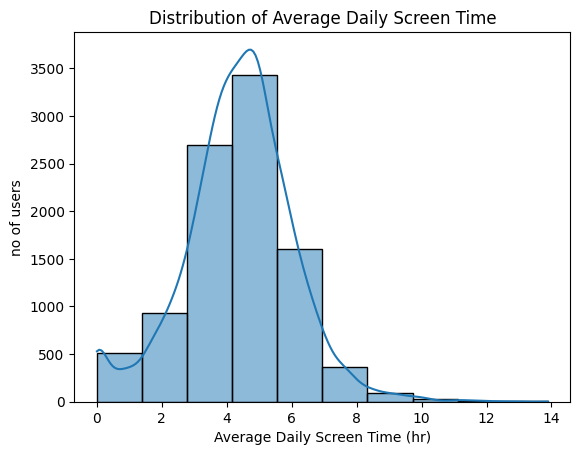

In [252]:
#histogram for avg_daily_screen_time_hr column
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['avg_daily_screen_time_hr'], bins=10,kde=True)
plt.xlabel('Average Daily Screen Time (hr)')
plt.ylabel('no of users')
plt.title('Distribution of Average Daily Screen Time')
plt.show()

### Insight:
- Most users spend 5-6 hours daily on screen.
- Peak usage is around 5 hours.
- Very few users spend less than 2 hours.
- Some users spend 8+ hours, indicating possible heavy usage/outliers

### boxplot 

Text(0.5, 1.0, 'Boxplot of Average Daily Screen Time')

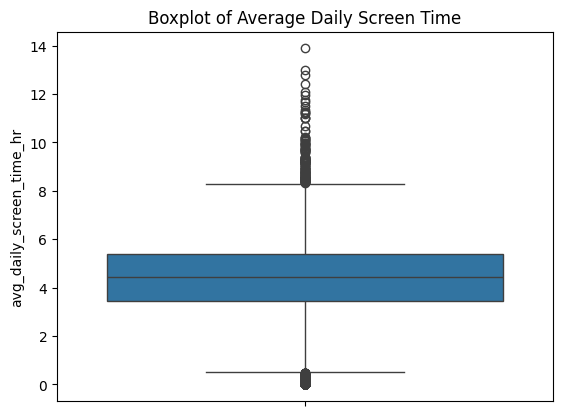

In [253]:
#boxplot for avg_daily_screen_time_hr
sns.boxplot(y='avg_daily_screen_time_hr',data=df)
plt.title('Boxplot of Average Daily Screen Time')
 

### Insight
- The median screen time is approximately 4 hours per day.
- 50% of users spend between 3 to 5 hours daily.
- There are multiple high-value outliers above 8 hours, indicating heavy screen users.
- A few low-value outliers near 0 hours are also present

### Density Plot

<function matplotlib.pyplot.show(close=None, block=None)>

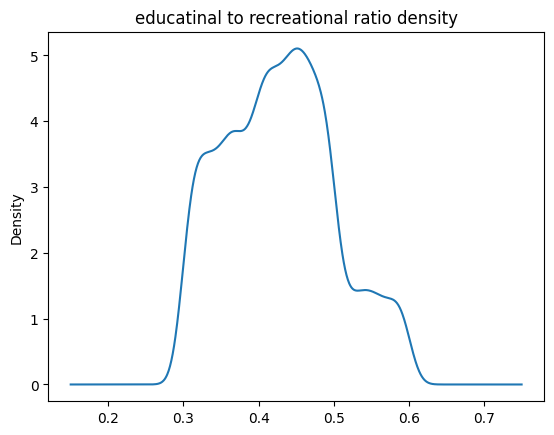

In [254]:
#creating a 
df['educational_to_recreational_ratio'].plot(kind='density')
plt.title("educatinal to recreational ratio density")
plt.show

## Univariate-Categorical

### Countplot

Text(0.5, 1.0, 'Count of Users by Primary Device')

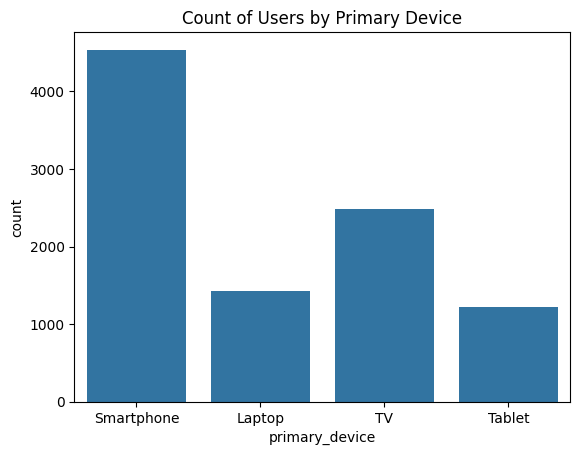

In [255]:
#countplotfor primary_device column
sns.countplot(x='primary_device',data=df)
plt.title('Count of Users by Primary Device')

### Insight
- Smartphone is the most commonly used primary device.
- TV is the second most used device.
- Laptop usage is moderate compared to smartphones and TVs.
- Tablet is the least used primary device

### bar chart 

Text(0.5, 1.0, 'Count of Users by Health Issue Present')

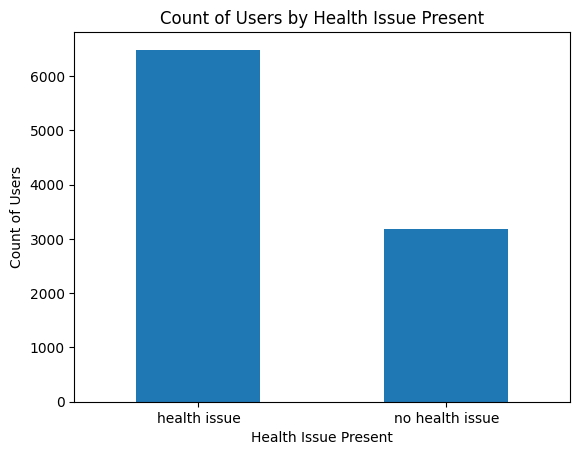

In [256]:
#bar chart for health_issue_present column
df['health_issue_present'].value_counts().plot(kind='bar',rot=360)
plt.xlabel('Health Issue Present')
plt.ylabel('Count of Users')
plt.title('Count of Users by Health Issue Present')

### Insight:
- Majority of users report having a health issue.
- Users with health issues are significantly higher than those without

### Pie Chart

Text(0, 0.5, '')

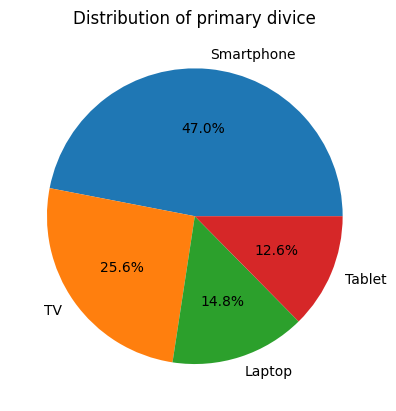

In [257]:
#pie chart for primary divice
df['primary_device'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Distribution of primary divice')
plt.ylabel('')#remove y-axis label for better visualization


### Insight

- Most users use a smartphone as their main device (47%).
- TV is the second most used device (25.6%).
- Laptops (14.8%) and tablets (12.6%) are used by fewer people.
- Overall, users prefer mobile devices more than traditional computing devices.

### Donut Chart

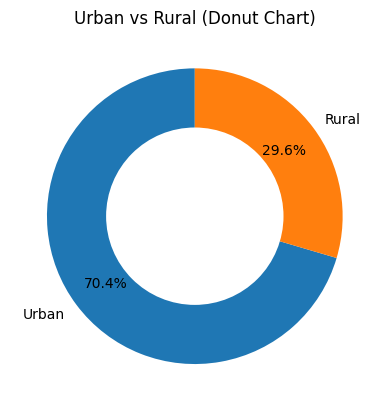

In [258]:
#create donut chart for urban or rural
counts = df['urban_or_rural'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',pctdistance=0.75,startangle=90)
centre_circle = plt.Circle((0,0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title("Urban vs Rural (Donut Chart)")
plt.show()


### Insight

- Most users are from urban areas (70.4%).
- Rural users account for 29.6% of the total.
- The dataset is largely dominated by the urban population.
- Urban users are more than twice the number of rural users

# Bivariate Analyisi

### Scatter plot

Text(0.5, 1.0, 'Age vs Average Daily Screen Time')

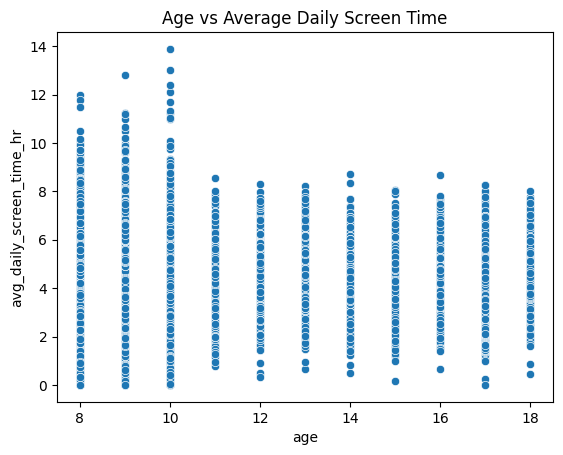

In [259]:
#Numerical vs NUmerical
sns.scatterplot(x='age',y='avg_daily_screen_time_hr',data=df)
plt.title('Age vs Average Daily Screen Time')

### Boxplot

Text(0.5, 1.0, 'Average Daily Screen Time by Gender')

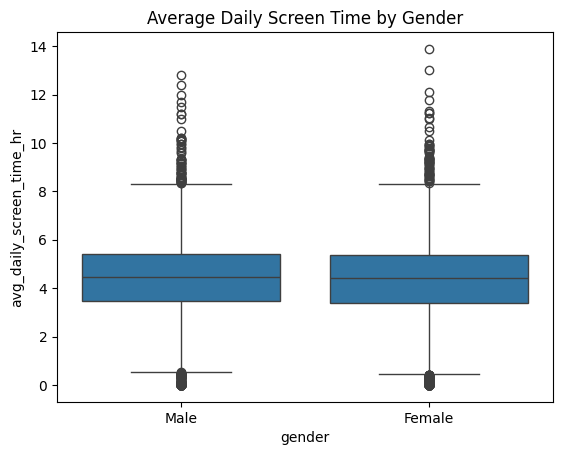

In [260]:
#numerical vs categorical
sns.boxplot(x='gender',y='avg_daily_screen_time_hr',data=df)
plt.title('Average Daily Screen Time by Gender')

### Insight
- The median screen time is almost similar for both males and females (around 4 hours).
- Both genders have high-value outliers above 8 hours.
- Overall, there is no major difference in average daily screen time between males and females.

### Boxplot

Text(0.5, 1.0, 'Average Daily Screen Time by Health Issue Present')

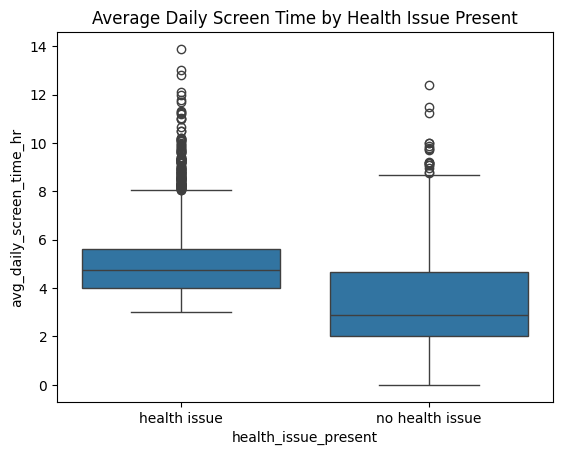

In [261]:


sns.boxplot(x='health_issue_present',y='avg_daily_screen_time_hr',data=df)
plt.title('Average Daily Screen Time by Health Issue Present')

### Insight
- Users with health issues have higher screen time.
- Median screen time is higher in the health issue group.
- Users without health issues have lower screen time.
- This suggests a possible relationship between higher screen time and health issues

### violinplot

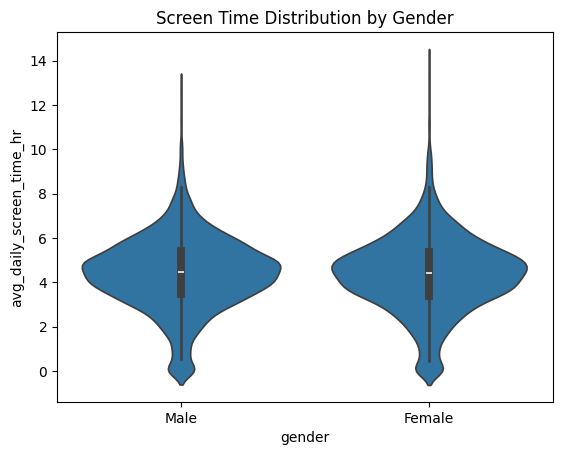

In [262]:
#numerical vs categorical
sns.violinplot(x='gender', y='avg_daily_screen_time_hr', data=df)
plt.title("Screen Time Distribution by Gender")
plt.show()

### stacked bar chart

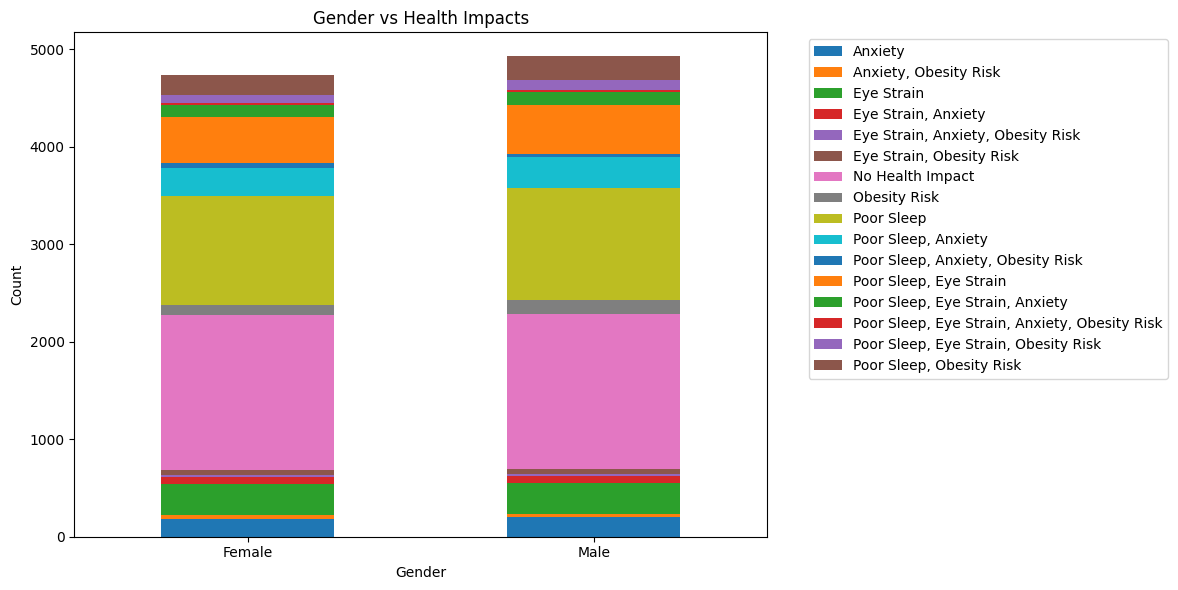

In [263]:
#categorical vs categorical
ct = pd.crosstab(df['gender'], df['health_impacts'])
fig, ax = plt.subplots(figsize=(12,6))
ct.plot(kind='bar', stacked=True, ax=ax,rot=360)
ax.set_title("Gender vs Health Impacts")
ax.set_xlabel("Gender")
ax.set_ylabel("Count")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Insight
- Both males and females report similar patterns of health impacts.
- Poor sleep appears to be one of the most common health issues across both genders.

### heatmap

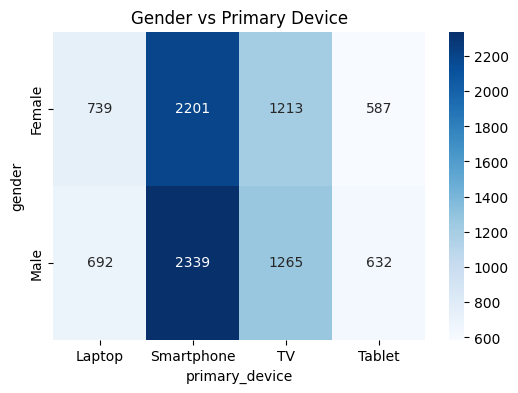

In [264]:
#categorical vs categoricl
plt.figure(figsize=(6,4))
sns.heatmap(pd.crosstab(df['gender'], df['primary_device']), annot=True, fmt="d",cmap="Blues")
plt.title("Gender vs Primary Device")
plt.show()

### Insight
- Smartphone is the most preferred device for both genders (Female: 2201, Male: 2339).
- Males use smartphones slightly more than females.
- TV is the second most used device for both genders (Male: 1265, Female: 1213).
- Laptop and Tablet usage are lower compared to smartphones and TVs.
- Overall device usage patterns are very similar across genders, with no major differences.

### stacked bar chart

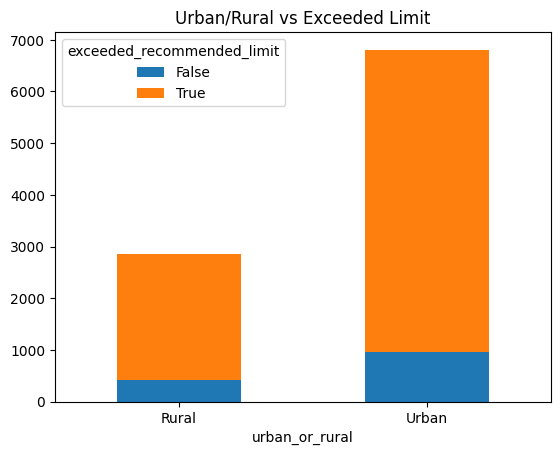

In [265]:
#categoical vs categorical
pd.crosstab(df['urban_or_rural'], df['exceeded_recommended_limit']).plot(kind='bar', stacked=True,rot=360)
plt.title("Urban/Rural vs Exceeded Limit")
plt.show()

### Insight
-  A higher number of urban users exceeded the recommended screen time limit compared to rural users.
- In both urban and rural groups, the majority of users have exceeded the recommended limit.
- Urban users contribute the largest share of users who exceeded the limit.
- Rural users also show exceedance, but the total count is lower than urban users.

### grouped bar chart

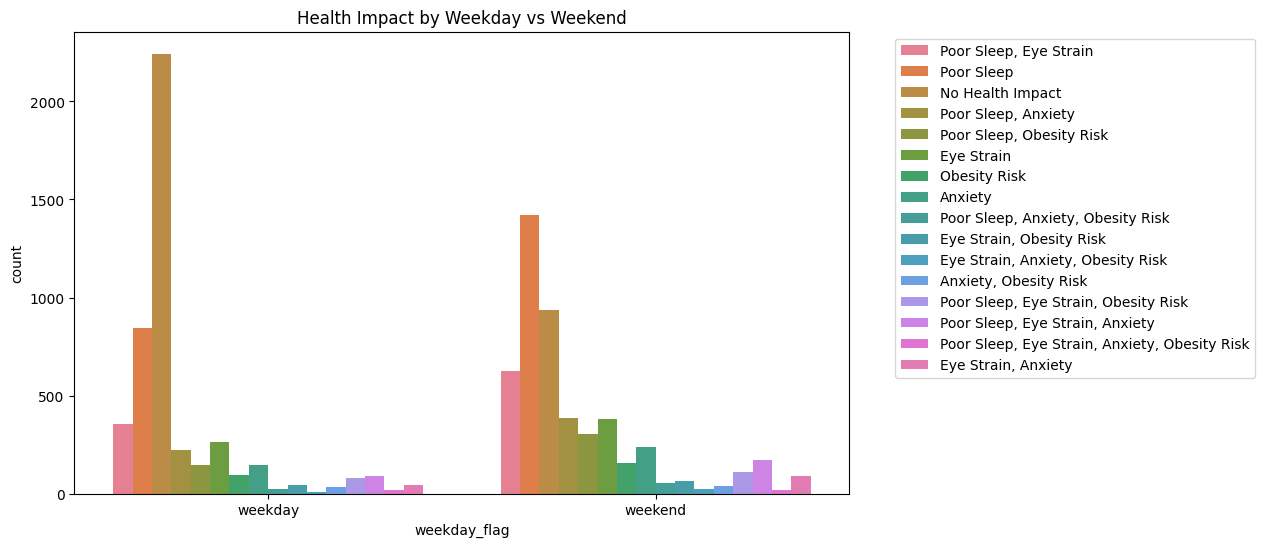

In [266]:
#categorical vs caregorical
plt.figure(figsize=(10,6))   
sns.countplot(x='weekday_flag', hue='health_impacts', data=df)
plt.title("Health Impact by Weekday vs Weekend")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  
plt.xticks(rotation=0)
plt.show()

Text(0.5, 1.0, 'Count of Users by Primary Device and Health Issue Present')

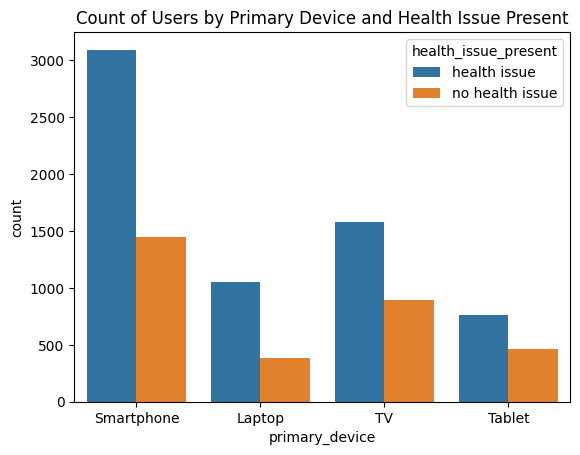

In [267]:
#categorical vs caregorical
sns.countplot(x='primary_device',hue='health_issue_present',data=df)
plt.title('Count of Users by Primary Device and Health Issue Present')

### Insight
- For every primary device category, the number of users reporting health issues is higher than those without health issues.
- Smartphone users show the highest count of reported health issues among all devices.
- TV users also demonstrate a notable number of health issue reports, though lower than smartphone users.
- Laptop and tablet users show comparatively lower counts of reported health issues

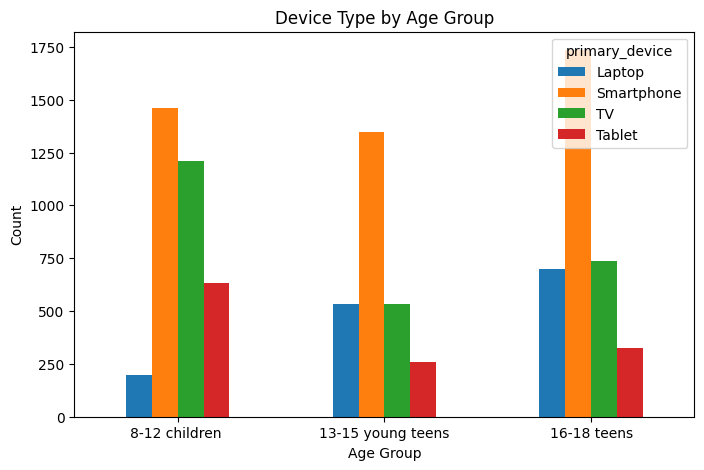

In [268]:
#categorical vs caregorical
pd.crosstab(df['age_group'], df['primary_device']).plot(kind='bar', figsize=(8,5),rot=360)
plt.title("Device Type by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()#

### Insight
- Smartphones are the most preferred device across all age groups.
- In the 8–12 age group, TV usage is also relatively high compared to other devices.
- Laptop usage increases with age, being highest among 16–18 teens.
- Tablet usage is higher among younger children (8–12) and decreases in the 13–15 group.
- Teens (16–18) show more balanced usage across smartphones, laptops, and TV compared to younger groups.

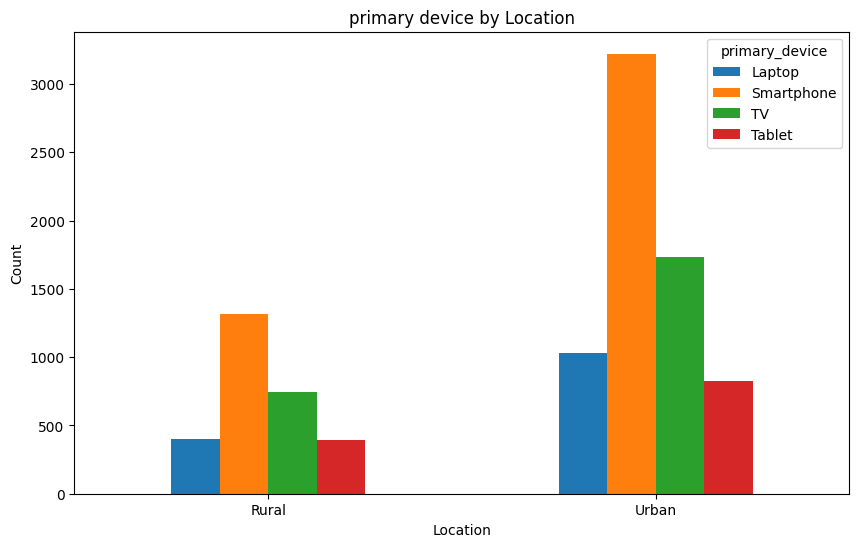

In [269]:
#categorical vs caregorical
pd.crosstab(df['urban_or_rural'], df['primary_device']).plot(kind='bar', figsize=(10,6),rot=360)
plt.title("primary device by Location")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()

### Insight
- Smartphones are the most used primary device in both rural and urban areas.
- Device usage is higher in urban areas across all device types.
- TV usage is the second most common device in both locations.
- Laptop and tablet usage are comparatively lower than smartphones and TVs.
- Urban users show significantly higher counts for every device compared to rural users.

In [270]:
df.to_csv("cleaned_Indian_Kids_Screen_Time.csv",index=False)